# K-Nearest Neighbors (KNN) - Telco Customer Churn

Predicting customer churn using the KNN classification algorithm.

In [3]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import pandas as pd
import matplotlib.ticker as ticker
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
%matplotlib inline

In [4]:
# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Data info and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# TotalCharges might have blanks — coerce to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing TotalCharges:', df['TotalCharges'].isnull().sum())

# Drop rows with missing TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)
print('Shape after drop:', df.shape)

Missing TotalCharges: 11
Shape after drop: (7032, 21)


In [8]:
# Drop customerID (not a feature)
df.drop('customerID', axis=1, inplace=True)

# Convert target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [9]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Categorical:', cat_cols)
print('Numerical:', num_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [10]:
# One-hot encode categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print('Encoded shape:', X.shape)
X.head()

Encoded shape: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [11]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 4922
Test size: 2110


In [12]:
# Feature scaling (essential for KNN)
scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Train KNN with k=5
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluation
print('Accuracy:', metrics.accuracy_score(y_test, y_pred))
print('Precision:', metrics.precision_score(y_test, y_pred))
print('Recall:', metrics.recall_score(y_test, y_pred))
print('F1-score:', metrics.f1_score(y_test, y_pred))
print()
print('Confusion Matrix:')
print(metrics.confusion_matrix(y_test, y_pred))

Accuracy: 0.7459715639810427
Precision: 0.5225225225225225
Recall: 0.5169340463458111
F1-score: 0.5197132616487455

Confusion Matrix:
[[1284  265]
 [ 271  290]]


In [14]:
# Find optimal k (1 to 30)
k_range = range(1, 31)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(metrics.accuracy_score(y_test, y_pred))

best_k = k_range[np.argmax(scores)]
best_acc = max(scores)
print(f'Best k: {best_k} with accuracy: {best_acc:.4f}')

Best k: 24 with accuracy: 0.7858


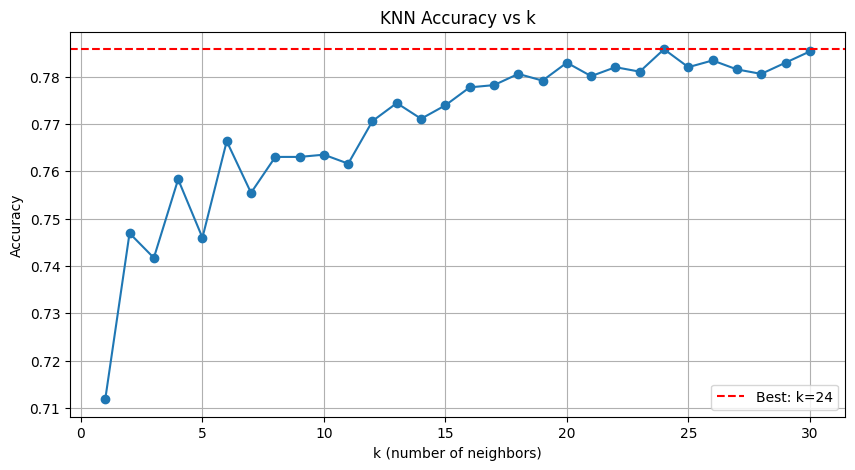

In [15]:
# Plot accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_range, scores, marker='o')
plt.axhline(y=best_acc, color='r', linestyle='--', label=f'Best: k={best_k}')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Retrain with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

print(f'Final model (k={best_k}) performance:')
print('Accuracy:', metrics.accuracy_score(y_test, y_pred_best))
print('Precision:', metrics.precision_score(y_test, y_pred_best))
print('Recall:', metrics.recall_score(y_test, y_pred_best))
print('F1-score:', metrics.f1_score(y_test, y_pred_best))

Final model (k=24) performance:
Accuracy: 0.785781990521327
Precision: 0.6066536203522505
Recall: 0.5525846702317291
F1-score: 0.5783582089552238


In [17]:
# Summary
print('KNN pipeline complete.')
print(f'- Dataset: Telco Customer Churn ({len(df)} samples)')
print(f'- Features after encoding: {X.shape[1]}')
print(f'- Best k: {best_k}')
print(f'- Test accuracy: {best_acc:.4f}')

KNN pipeline complete.
- Dataset: Telco Customer Churn (7032 samples)
- Features after encoding: 30
- Best k: 24
- Test accuracy: 0.7858
